In [24]:
import pandas as pd
import numpy as np
import urllib.request
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

# Configuración visual de las gráficas
sns.set_theme(style="whitegrid")

# ==========================================
# 1. EXTRACCIÓN Y DIAGNÓSTICO DE DATOS
# ==========================================
url_repositorio = "https://ti.arc.nasa.gov/m/project/prognostic-repository/CMAPSSData.zip"
archivo_zip = "CMAPSSData.zip"
directorio_extraccion = "./datos_motor"  # <-- Ajustado a tu nueva ruta

# Descarga automática si no existe la carpeta
if not os.path.exists(directorio_extraccion):
    os.makedirs(directorio_extraccion)
    print(f"Descargando el dataset original en '{directorio_extraccion}'...")
    req = urllib.request.Request(url_repositorio, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(archivo_zip, 'wb') as out_file:
        out_file.write(response.read())
    
    with zipfile.ZipFile(archivo_zip, 'r') as zip_ref:
        zip_ref.extractall(directorio_extraccion)
    os.remove(archivo_zip)

# Definimos las columnas
column_names = ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
column_names.extend(sensor_names)

ruta_train = os.path.join(directorio_extraccion, 'train_FD001.txt')

print("\n" + "="*50)
print("📌 PASO 1: DIAGNÓSTICO DE ARCHIVOS")
print("="*50)

# Diagnóstico: Verificar si la carpeta existe y qué archivos tiene
if os.path.exists(directorio_extraccion):
    archivos = os.listdir(directorio_extraccion)
    print(f"📂 Archivos detectados en '{directorio_extraccion}':\n{archivos[:5]}... (mostrando los primeros)\n")
else:
    print(f"❌ ¡Error! La carpeta '{directorio_extraccion}' no existe en tu directorio actual.")

# Intento de lectura segura
if os.path.exists(ruta_train):
    print("⏳ Cargando el archivo, por favor espera...")
    df_train = pd.read_csv(ruta_train, sep=r'\s+', header=None, names=column_names)
    print("✅ ¡PASO 1 COMPLETADO: EXTRACCIÓN DE DATOS EXITOSA!")
    print(f"El dataset tiene {df_train.shape[0]} filas y {df_train.shape[1]} columnas.")
    




📌 PASO 1: DIAGNÓSTICO DE ARCHIVOS
📂 Archivos detectados en './datos_motor':
['Damage Propagation Modeling.pdf', 'readme.txt', 'RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt']... (mostrando los primeros)

⏳ Cargando el archivo, por favor espera...
✅ ¡PASO 1 COMPLETADO: EXTRACCIÓN DE DATOS EXITOSA!
El dataset tiene 20631 filas y 26 columnas.



📌 PASO 2: EVALUACIÓN DE DATOS
Sensores de baja varianza descartados:
 ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


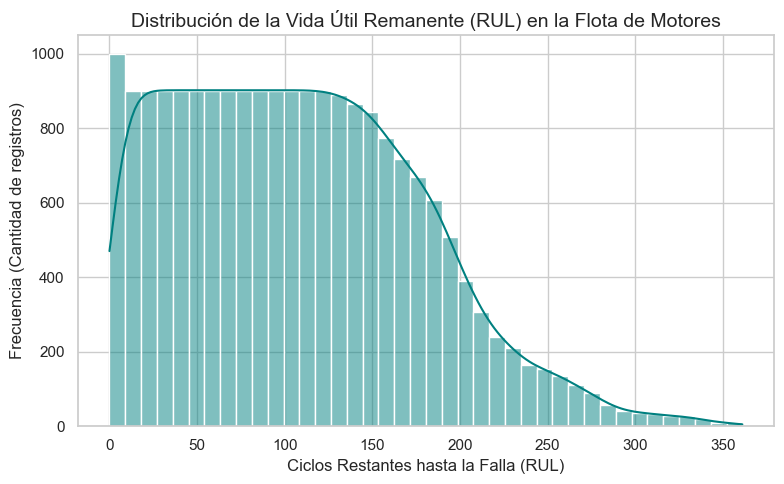

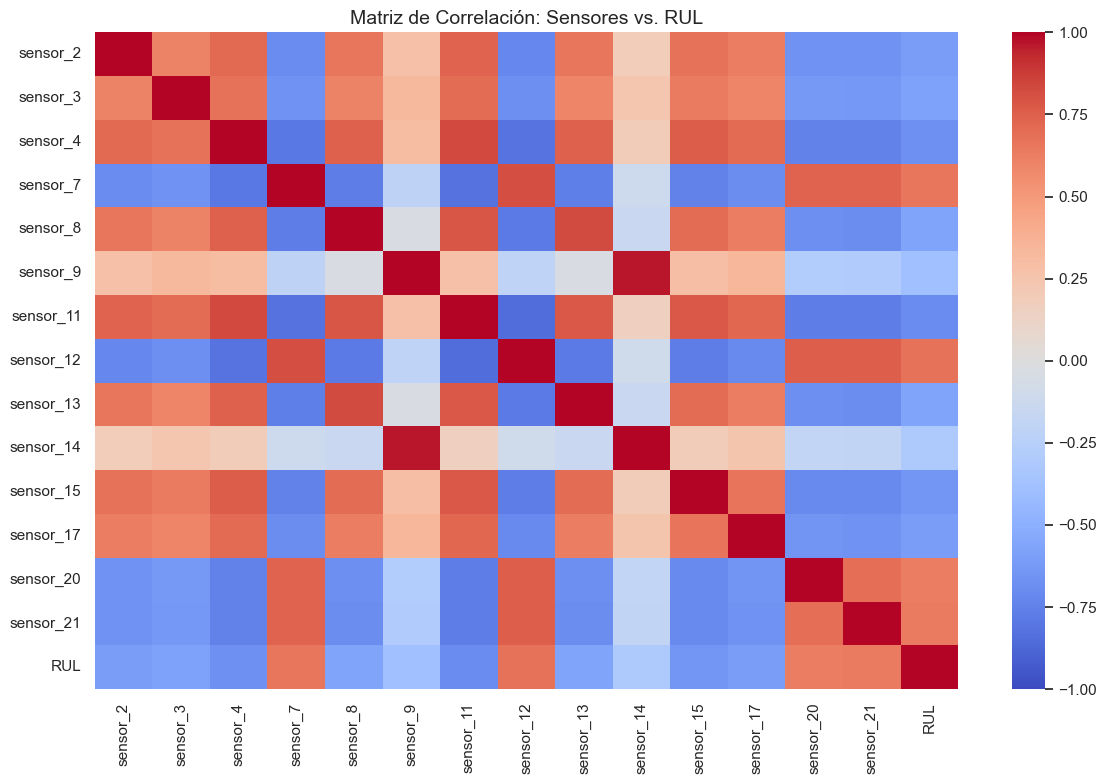

In [30]:
# ==========================================
# 2. EVALUACIÓN Y PREPROCESAMIENTO DE DATOS
# ==========================================

# Cálculo del RUL (Remaining Useful Life)
max_cycles = df_train.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.rename(columns={'time_in_cycles': 'max_cycles'}, inplace=True)
df_train = df_train.merge(max_cycles, on='unit_number', how='left')
df_train['RUL'] = df_train['max_cycles'] - df_train['time_in_cycles']
df_train.drop('max_cycles', axis=1, inplace=True)

# Filtro de Sensores
sensor_std = df_train[sensor_names].std()
constant_sensors = sensor_std[sensor_std < 0.01].index.tolist()
df_clean = df_train.drop(columns=constant_sensors)

print("\n" + "="*50)
print("📌 PASO 2: EVALUACIÓN DE DATOS")
print("="*50)
std_df = pd.DataFrame({'Sensor': sensor_std.index, 'Varianza (Std)': sensor_std.values})
std_df['Estado'] = np.where(std_df['Varianza (Std)'] < 0.01, 'Descartado', 'Mantenido')
print("Sensores de baja varianza descartados:\n", constant_sensors)

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# ==========================================
# GRÁFICAS DEL PASO 2 (ANÁLISIS EXPLORATORIO)
# ==========================================

# GRÁFICA 1: Distribución del RUL (Vida Útil Remanente)
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['RUL'], bins=40, kde=True, color='teal')
plt.title('Distribución de la Vida Útil Remanente (RUL) en la Flota de Motores', fontsize=14)
plt.xlabel('Ciclos Restantes hasta la Falla (RUL)')
plt.ylabel('Frecuencia (Cantidad de registros)')
plt.tight_layout()
plt.show()

# GRÁFICA 2: Matriz de Correlación (Justificación de Selección de Variables)
plt.figure(figsize=(12, 8))

# Filtramos solo las columnas de sensores que sobrevivieron y el RUL
columnas_analisis = [col for col in df_clean.columns if 'sensor' in col] + ['RUL']
matriz_corr = df_clean[columnas_analisis].corr()

# Generamos un mapa de calor (Heatmap)
sns.heatmap(matriz_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Sensores vs. RUL', fontsize=14)
plt.tight_layout()
plt.show()


Normalizando las variables de los sensores...
Entrenando el gemelo digital (Random Forest)...

📌 PASO 3: MODELADO PREDICTIVO
| Métrica               |    Valor |
|:----------------------|---------:|
| Exactitud (Accuracy)  | 0.966077 |
| Precisión (Precision) | 0.898671 |
| Sensibilidad (Recall) | 0.872581 |
| F1-Score              | 0.885434 |


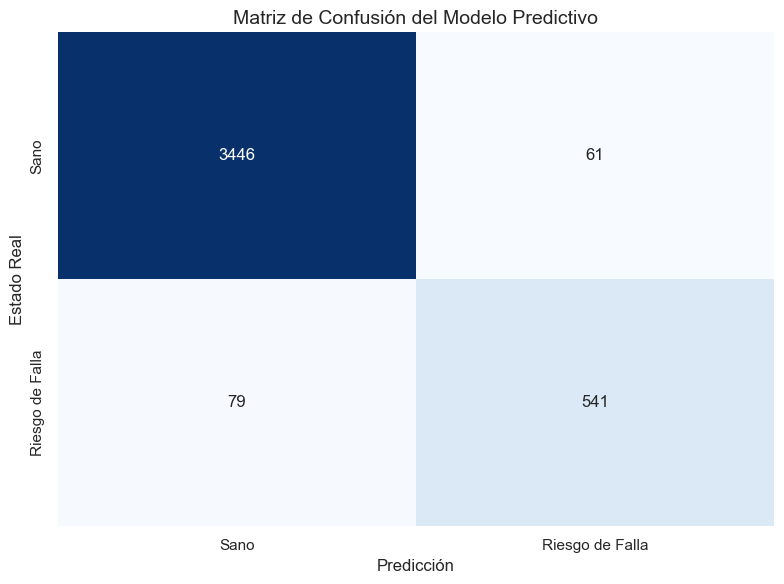

C:\Users\10138083\AppData\Local\Temp\ipykernel_29924\942584830.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancias, x='Importancia', y='Sensor', palette='viridis')


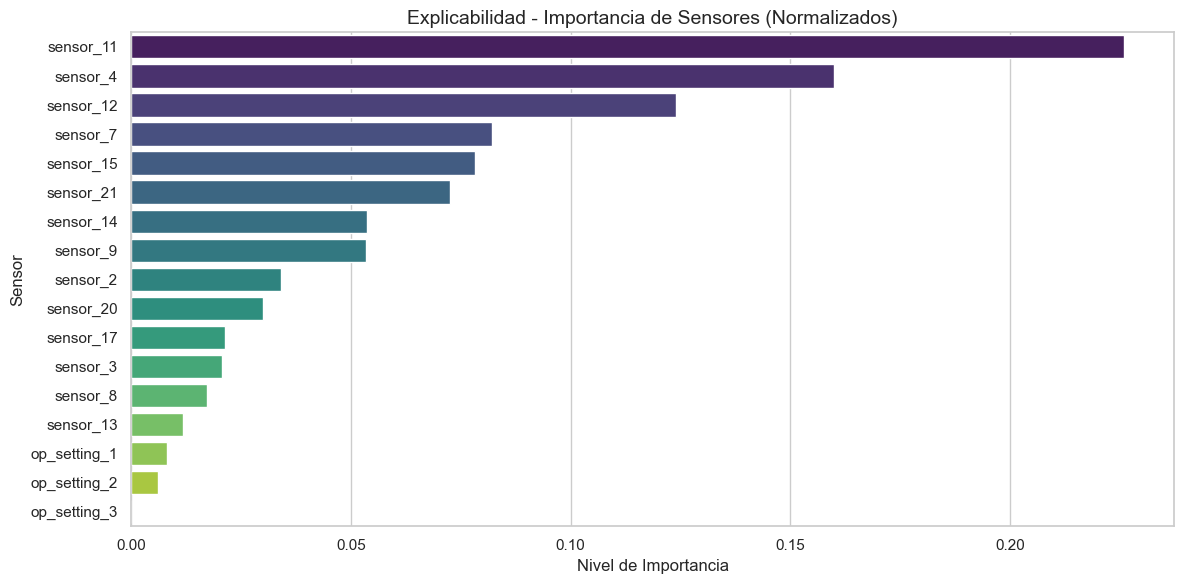

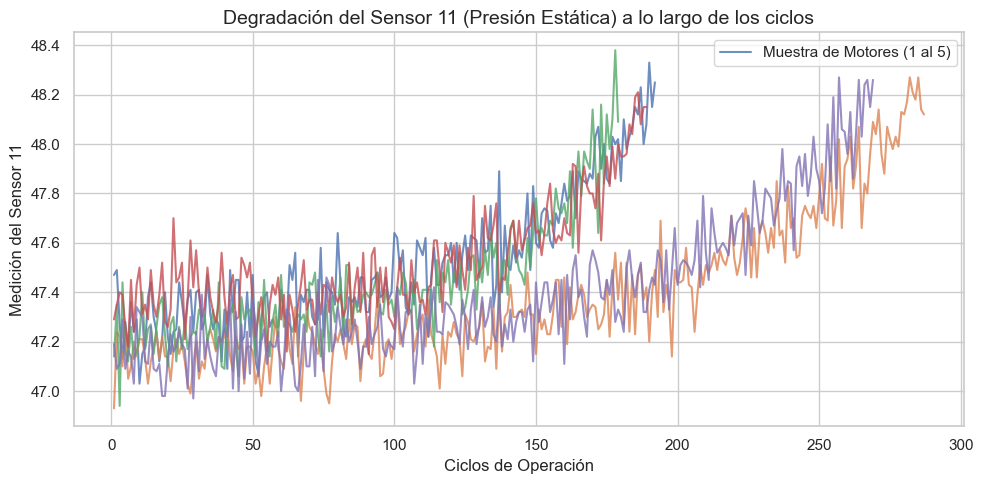

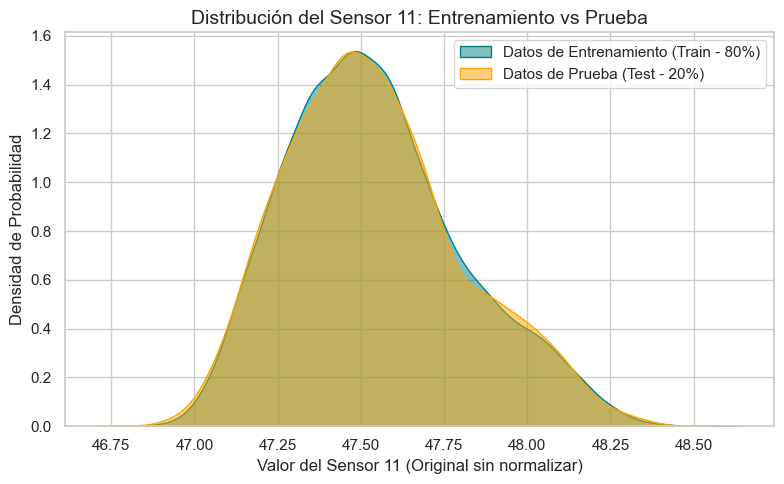

In [34]:

    # ==========================================
    # 3. MODELADO Y MÉTRICAS (PREDICCIÓN DE FALLAS)
    # ==========================================
    ventana_riesgo = 30
    df_clean['label_riesgo'] = np.where(df_clean['RUL'] <= ventana_riesgo, 1, 0)

    features = [col for col in df_clean.columns if col not in ['unit_number', 'time_in_cycles', 'RUL', 'label_riesgo']]
    X = df_clean[features]
    y = df_clean['label_riesgo']

    # 3.1 División de datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 3.2 Normalización (StandardScaler)
    print("\nNormalizando las variables de los sensores...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

    # 3.3 Entrenamiento del modelo
    print("Entrenando el gemelo digital (Random Forest)...")
    modelo_rf = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_split=5, random_state=42)
    modelo_rf.fit(X_train_scaled, y_train)

    # 3.4 Predicciones y Métricas
    y_pred = modelo_rf.predict(X_test_scaled)
    metricas = {
        'Métrica': ['Exactitud (Accuracy)', 'Precisión (Precision)', 'Sensibilidad (Recall)', 'F1-Score'],
        'Valor': [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                  recall_score(y_test, y_pred), f1_score(y_test, y_pred)]
    }
    df_metricas = pd.DataFrame(metricas)

    print("\n" + "="*50)
    print("📌 PASO 3: MODELADO PREDICTIVO")
    print("="*50)
    print(df_metricas.to_markdown(index=False))

    # GRÁFICA 1: Matriz de Confusión
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=['Sano', 'Riesgo de Falla'], 
                yticklabels=['Sano', 'Riesgo de Falla'])
    plt.title('Matriz de Confusión del Modelo Predictivo', fontsize=14)
    plt.xlabel('Predicción')
    plt.ylabel('Estado Real')
    plt.tight_layout()
    plt.show()

    # GRÁFICA 2: Explicabilidad del Modelo
    importancias = modelo_rf.feature_importances_
    df_importancias = pd.DataFrame({'Sensor': features, 'Importancia': importancias})
    df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_importancias, x='Importancia', y='Sensor', palette='viridis')
    plt.title('Explicabilidad - Importancia de Sensores (Normalizados)', fontsize=14)
    plt.xlabel('Nivel de Importancia')
    plt.ylabel('Sensor')
    plt.tight_layout()
    plt.show()
# ==========================================
# GRÁFICAS ADICIONALES: SENSOR 11 Y EVALUACIÓN DE PARTICIÓN
# ==========================================

# GRÁFICA 4: Comportamiento del Sensor 11 (La variable más importante)
plt.figure(figsize=(10, 5))
# Graficamos la trayectoria de los primeros 5 motores para ver el patrón de degradación
for unit in [1, 2, 3, 4, 5]: 
        motor_data = df_clean[df_clean['unit_number'] == unit]
        sns.lineplot(data=motor_data, x='time_in_cycles', y='sensor_11', alpha=0.8, 
                 label=f'Motor {unit}' if unit == 1 else None)

plt.title('Degradación del Sensor 11 (Presión Estática) a lo largo de los ciclos', fontsize=14)
plt.xlabel('Ciclos de Operación')
plt.ylabel('Medición del Sensor 11')
plt.legend(['Muestra de Motores (1 al 5)'])
plt.tight_layout()
plt.show()


# GRÁFICA 5: Comparación de Distribución (Train vs Test)
plt.figure(figsize=(8, 5))
# Comparamos cómo quedó distribuida la variable más importante en ambos conjuntos
sns.kdeplot(X_train['sensor_11'], label='Datos de Entrenamiento (Train - 80%)', fill=True, color='teal', alpha=0.5)
sns.kdeplot(X_test['sensor_11'], label='Datos de Prueba (Test - 20%)', fill=True, color='orange', alpha=0.5)

plt.title('Distribución del Sensor 11: Entrenamiento vs Prueba', fontsize=14)
plt.xlabel('Valor del Sensor 11 (Original sin normalizar)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.tight_layout()
plt.show()
